# Entrenamiento Modelo CNN Multi-Horizonte

Este notebook entrena un modelo CNN para predecir la probabilidad de incumplimiento de créditos a 18 horizontes de tiempo.

## Entradas
- `output/datasets/datos_preprocesados.csv` (generado por EDA.ipynb)

## Salidas
- Modelo CNN entrenado
- Scaler para normalización
- Archivo de configuración con métricas

## Criterio de éxito
- El modelo se entrena sin errores
- Se guardan todos los artefactos requeridos
- Se imprime resumen de métricas

In [ ]:
import json
import logging
import os
import sys
from datetime import datetime

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras import Model, layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Configurar logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    force=True
)
logger = logging.getLogger(__name__)

## Configuración del notebook

In [ ]:
# Configuración de rutas
PATH_INPUT = "output/datasets/datos_preprocesados.csv"
PATH_OUTPUT = "output/modelos_cnn"
os.makedirs(PATH_OUTPUT, exist_ok=True)

# Configuración del modelo
VENTANA_CNN = 6  # Meses de historial para la secuencia
MAX_HORIZONTE = 18  # Meses futuros a predecir
EPOCHS = 100
BATCH_SIZE = 32
PATIENCE = 10  # Early stopping

print(f"Configuración:")
print(f"- Ventana CNN: {VENTANA_CNN} meses")
print(f"- Máximo horizonte: {MAX_HORIZONTE} meses")
print(f"- Épocas máximas: {EPOCHS}")
print(f"- Batch size: {BATCH_SIZE}")

## Carga de datos

In [ ]:
# Cargar datos preprocesados
df = pd.read_csv(PATH_INPUT)
df['mes'] = pd.to_datetime(df['mes'])

print(f"Datos cargados: {len(df):,} registros")
print(f"Columnas: {len(df.columns)}")
print(f"\nDistribución crisis_flag:")
print(df['crisis_flag'].value_counts())
print(f"\nPrimeras filas:")
df.head()

## Preprocesamiento y features

In [ ]:
def preprocesar_datos(df):
    """
    Preprocesa datos para CNN.
    - Remueve features con cero varianza.
    - Recorta outliers al percentil 1-99.
    """
    df_features = df.copy()
    df_features['mes'] = pd.to_datetime(df_features['mes'])
    
    features_numericas = [
        'num_creditos', 'monto_total', 'monto_promedio', 'plazo_promedio',
        'tasa_interes_promedio', 'saldo_promedio', 'total_costo_judicial',
        'total_gestion_cobro', 'total_notificaciones', 'tot_dias_mora_promedio',
        'tot_num_moras_promedio', 'mora_promedio', 'creditos_judiciales',
        'creditos_cerrados', 'tasa_judicial', 'tasa_cierre',
        'tasa_mora_90', 'creditos_por_cliente', 'coef_variacion_montos',
        'tasa_crecimiento_creditos', 'tasa_crecimiento_monto',
    ]
    
    features_existentes = [f for f in features_numericas if f in df_features.columns]
    
    # Remover features con cero varianza (siempre el mismo valor)
    features_limpias = []
    for f in features_existentes:
        if df_features[f].std() > 0:
            features_limpias.append(f)
        else:
            logger.info(f"Removida feature sin varianza: {f}")
    
    # Recortar outliers al percentil 1-99
    for f in features_limpias:
        q01 = df_features[f].quantile(0.01)
        q99 = df_features[f].quantile(0.99)
        df_features[f] = df_features[f].clip(lower=q01, upper=q99)
    
    df_features = df_features.sort_values(['bloque_id', 'mes'])
    
    logger.info(f"Features seleccionadas: {len(features_limpias)}")
    logger.info(f"Bloques unicos: {df_features['bloque_id'].nunique()}")
    
    return df_features, features_limpias

In [ ]:
df_features, features_numericas = preprocesar_datos(df)
print(f"\nFeatures para el modelo ({len(features_numericas)}):")
print(features_numericas)

## Creación de secuencias temporales

In [ ]:
def crear_secuencias_cnn(df, bloque_id, features, target, ventana, max_horizonte):
    """
    Genera secuencias temporales para entrenamiento de una CNN multi-horizonte.
    Retorna X, y y las fechas de prediccion para split temporal.
    """
    df_bloque = df[df['bloque_id'] == bloque_id].sort_values('mes')
    
    if len(df_bloque) < ventana + max_horizonte:
        return None, None, None
    
    X_sequences = []
    y_sequences = []
    fechas = []
    
    for i in range(len(df_bloque) - ventana - max_horizonte + 1):
        X_seq = df_bloque[features].iloc[i:i+ventana].values
        y_seq = []
        
        for h in range(1, max_horizonte + 1):
            if i + ventana + h - 1 < len(df_bloque):
                y_val = df_bloque[target].iloc[i + ventana + h - 1]
                y_seq.append(y_val)
            else:
                y_seq.append(0)
        
        X_sequences.append(X_seq)
        y_sequences.append(y_seq)
        fechas.append(df_bloque['mes'].iloc[i + ventana - 1])
    
    return np.array(X_sequences), np.array(y_sequences), np.array(fechas)

In [ ]:
# Generar secuencias para todos los bloques
X_all = []
y_all = []
fechas_all = []
bloques_validos = []

for bloque in df_features['bloque_id'].unique():
    X_seq, y_seq, fechas_seq = crear_secuencias_cnn(
        df_features, bloque, features_numericas, 'crisis_flag',
        VENTANA_CNN, MAX_HORIZONTE
    )
    if X_seq is not None and len(X_seq) > 0:
        X_all.extend(X_seq)
        y_all.extend(y_seq)
        fechas_all.extend(fechas_seq)
        bloques_validos.append(bloque)

X_cnn = np.array(X_all)
y_cnn = np.array(y_all)
fechas_cnn = np.array(fechas_all)

print(f"Secuencias generadas:")
print(f"- X shape: {X_cnn.shape}")
print(f"- y shape: {y_cnn.shape}")
print(f"- Fechas: {fechas_cnn.min()} a {fechas_cnn.max()}")
print(f"- Bloques válidos: {len(bloques_validos)}")

## Normalización y división de datos

In [ ]:
# Validación antes de normalizar
if X_cnn.size == 0 or X_cnn.ndim != 3:
    min_meses = VENTANA_CNN + MAX_HORIZONTE
    meses_por_bloque = df_features.groupby('bloque_id').size()
    resumen = meses_por_bloque.describe().to_dict()
    
    raise ValueError(
        "No se generaron secuencias CNN. "
        f"Se requieren al menos {min_meses} meses por bloque "
        f"(VENTANA_CNN={VENTANA_CNN}, MAX_HORIZONTE={MAX_HORIZONTE}). "
        f"Bloques válidos: {len(bloques_validos)}. "
        f"Resumen meses/bloque: {resumen}"
    )

# Normalizar features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_cnn.reshape(-1, X_cnn.shape[-1])).reshape(X_cnn.shape)

# Ordenar por mes_prediccion para split temporal (sin data leakage)
sort_idx = np.argsort(fechas_cnn)
X_scaled = X_scaled[sort_idx]
y_cnn = y_cnn[sort_idx]
fechas_cnn = fechas_cnn[sort_idx]
print(f'Fechas de prediccion: {fechas_cnn.min()} a {fechas_cnn.max()}')

# Split temporal 70/30
split_idx = int(len(X_scaled) * 0.7)
X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]

# Preparar listas de targets por horizonte
y_train_list = [y_cnn[:split_idx, i] for i in range(MAX_HORIZONTE)]
y_test_list = [y_cnn[split_idx:, i] for i in range(MAX_HORIZONTE)]

# Asegurar shapes correctos
for i in range(len(y_train_list)):
    y_train_list[i] = np.asarray(y_train_list[i]).reshape(-1,)
for i in range(len(y_test_list)):
    y_test_list[i] = np.asarray(y_test_list[i]).reshape(-1,)

print(f"División de datos:")
print(f"- Train: {X_train.shape[0]:,} muestras")
print(f"- Test: {X_test.shape[0]:,} muestras")
print(f"- Features: {X_train.shape[2]}")
print(f"- Horizontes: {MAX_HORIZONTE}")

## Construcción del modelo CNN

In [ ]:
def crear_modelo_cnn_multioutput(input_shape, num_horizontes):
    """
    Crea un modelo CNN con múltiples salidas para predecir crisis en varios horizontes.
    """
    inputs = layers.Input(shape=input_shape)
    
    # Capa convolucional 1
    x = layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    
    # Capa convolucional 2
    x = layers.Conv1D(filters=128, kernel_size=3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.3)(x)
    
    # Capas densas
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    
    # Salidas múltiples (una por horizonte)
    outputs = []
    for i in range(num_horizontes):
        output = layers.Dense(1, activation='sigmoid', name=f'horizonte_{i+1}')(x)
        outputs.append(output)
    
    model = Model(inputs=inputs, outputs=outputs)
    
    # Métricas por horizonte
    metrics_dict = {
        f'horizonte_{i+1}': [
            'accuracy',
            tf.keras.metrics.Precision(name=f'precision_{i+1}'),
            tf.keras.metrics.Recall(name=f'recall_{i+1}'),
        ]
        for i in range(num_horizontes)
    }
    
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=metrics_dict
    )
    
    return model

In [ ]:
# Crear modelo
input_shape = X_train.shape[1:]
modelo_cnn = crear_modelo_cnn_multioutput(input_shape, MAX_HORIZONTE)

# Resumen del modelo
modelo_cnn.summary()

## Entrenamiento del modelo

In [25]:
# Callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        os.path.join(PATH_OUTPUT, 'best_model_cnn.keras'),
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

# División train/validation (80/20)
val_frac = 0.2
n_samples = X_train.shape[0]
val_size = int(n_samples * val_frac)
train_end = n_samples - val_size

X_train_final = X_train[:train_end]
X_val = X_train[train_end:]
y_train_final = [arr[:train_end] for arr in y_train_list]
y_val = [arr[train_end:] for arr in y_train_list]

# Sample weights para manejar desbalanceo de clases
# Keras no soporta class_weight con multi-output, usamos sample_weight
sample_weight_train = []
sample_weight_val = []
for h in range(MAX_HORIZONTE):
    y_h_train = y_train_final[h]
    n_pos = int(np.sum(y_h_train == 1))
    n_neg = int(np.sum(y_h_train == 0))
    total = n_pos + n_neg
    w_0 = total / (2.0 * n_neg) if n_neg > 0 else 1.0
    w_1 = total / (2.0 * n_pos) if n_pos > 0 else 1.0
    
    sw_train = np.where(y_h_train == 1, w_1, w_0).astype(np.float32)
    y_h_val = y_val[h]
    n_pos_v = int(np.sum(y_h_val == 1))
    n_neg_v = int(np.sum(y_h_val == 0))
    total_v = n_pos_v + n_neg_v
    w_0_v = total_v / (2.0 * n_neg_v) if n_neg_v > 0 else 1.0
    w_1_v = total_v / (2.0 * n_pos_v) if n_pos_v > 0 else 1.0
    sw_val = np.where(y_h_val == 1, w_1_v, w_0_v).astype(np.float32)
    
    sample_weight_train.append(sw_train)
    sample_weight_val.append(sw_val)
    print(f'  Horizonte {h+1}: crisis_train={n_pos} ({n_pos/total*100:.1f}%), w_1={w_1:.2f}')

print("\nIniciando entrenamiento con sample weights...")
historia = modelo_cnn.fit(
    X_train_final,
    y_train_final,
    validation_data=(X_val, y_val, sample_weight_val),
    sample_weight=sample_weight_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)


 99/101 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - horizonte_10_accuracy: 0.5713 - horizonte_10_loss: 0.7154 - horizonte_10_precision_10: 0.1430 - horizonte_10_recall_10: 0.3187 - horizonte_11_accuracy: 0.7939 - horizonte_11_loss: 0.7027 - horizonte_11_precision_11: 0.2040 - horizonte_11_recall_11: 0.0768 - horizonte_12_accuracy: 0.2506 - horizonte_12_loss: 0.7077 - horizonte_12_precision_12: 0.1655 - horizonte_12_recall_12: 0.8588 - horizonte_13_accuracy: 0.7734 - horizonte_13_loss: 0.7178 - horizonte_13_precision_13: 0.1835 - horizonte_13_recall_13: 0.1120 - horizonte_14_accuracy: 0.4277 - horizonte_14_loss: 0.7131 - horizonte_14_precision_14: 0.1585 - horizonte_14_recall_14: 0.5833 - horizonte_15_accuracy: 0.7642 - horizonte_15_loss: 0.7114 - horizonte_15_precision_15: 0.1690 - horizonte_15_recall_15: 0.1172 - horizonte_16_accuracy: 0.4201 - horizonte_16_loss: 0.7082 - horizonte_16_precision_16: 0.1494 - horizonte_16_recall_16: 0.5700 - horizonte_17_accuracy: 0.8116 - horizonte_17_loss: 0.7

## Evaluación del modelo

In [26]:
# Evaluar en conjunto de test
y_pred_proba_list = modelo_cnn.predict(X_test)

# Métricas para el primer horizonte (1 mes)
y_pred_1m = (y_pred_proba_list[0] > 0.5).astype(int).flatten()
y_test_1m = y_test_list[0]

test_acc = accuracy_score(y_test_1m, y_pred_1m)
test_prec = precision_score(y_test_1m, y_pred_1m, zero_division=0)
test_recall = recall_score(y_test_1m, y_pred_1m, zero_division=0)

print("=" * 60)
print("MÉTRICAS - Horizonte 1 mes")
print("=" * 60)
print(f"Accuracy: {test_acc:.4f}")
print(f"Precision: {test_prec:.4f}")
print(f"Recall: {test_recall:.4f}")

if len(np.unique(y_test_1m)) > 1:
    try:
        auc_score = roc_auc_score(y_test_1m, y_pred_proba_list[0].flatten())
        print(f"AUC-ROC: {auc_score:.4f}")
    except Exception as e:
        print(f"No se pudo calcular AUC-ROC: {e}")

print("\nReporte detallado:")
print(classification_report(y_test_1m, y_pred_1m))

print("Matriz de confusión:")
print(confusion_matrix(y_test_1m, y_pred_1m))

54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
MÉTRICAS - Horizonte 1 mes
Accuracy: 0.0901
Precision: 0.0901
Recall: 1.0000
AUC-ROC: 0.5000

Reporte detallado:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1566
           1       0.09      1.00      0.17       155

    accuracy                           0.09      1721
   macro avg       0.05      0.50      0.08      1721
weighted avg       0.01      0.09      0.01      1721

Matriz de confusión:
[[   0 1566]
 [   0  155]]


/home/ovelez/Documentos/cursos/Maestria/IADegreeThesis/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ovelez/Documentos/cursos/Maestria/IADegreeThesis/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ovelez/Documentos/cursos/Maestria/IADegreeThesis/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` 

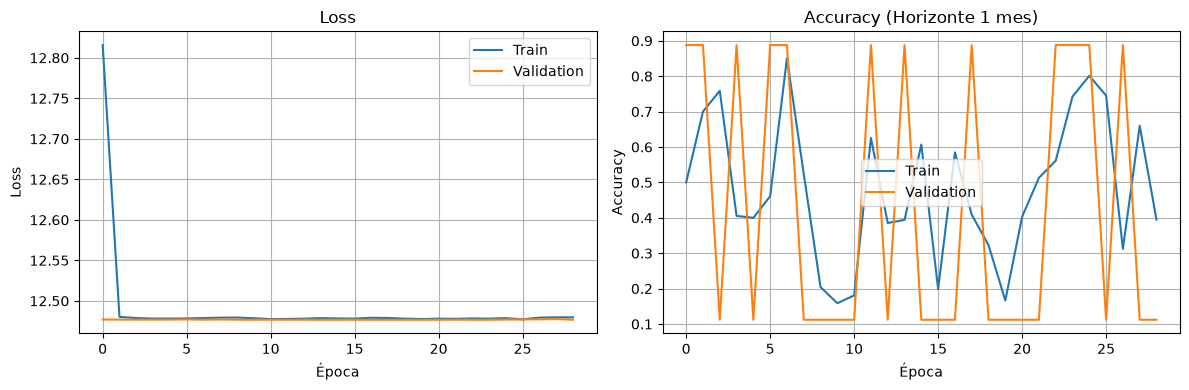

In [27]:
# Gráfica de entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(historia.history['loss'], label='Train')
axes[0].plot(historia.history['val_loss'], label='Validation')
axes[0].set_title('Loss')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy (primer horizonte)
axes[1].plot(historia.history[f'horizonte_1_accuracy'], label='Train')
axes[1].plot(historia.history[f'val_horizonte_1_accuracy'], label='Validation')
axes[1].set_title('Accuracy (Horizonte 1 mes)')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(PATH_OUTPUT, 'training_history.png'), dpi=150, bbox_inches='tight')
plt.show()

## Guardado de artefactos

In [28]:
# Guardar modelo
modelo_path = os.path.join(PATH_OUTPUT, 'modelo_cnn_multi_18m.keras')
modelo_cnn.save(modelo_path)
logger.info(f"Modelo guardado en: {modelo_path}")

# Guardar scaler
scaler_path = os.path.join(PATH_OUTPUT, 'scaler_multi_18m.pkl')
joblib.dump(scaler, scaler_path)
logger.info(f"Scaler guardado en: {scaler_path}")

# Guardar configuración y métricas
config = {
    'ventana_cnn': VENTANA_CNN,
    'max_horizonte': MAX_HORIZONTE,
    'features_numericas': features_numericas,
    'bloques_validos': bloques_validos,
    'metricas_finales': {
        'accuracy': float(test_acc),
        'precision': float(test_prec),
        'recall': float(test_recall),
    },
    'fecha_entrenamiento': datetime.now().isoformat(),
    'num_muestras_train': int(X_train.shape[0]),
    'num_muestras_test': int(X_test.shape[0]),
}

config_path = os.path.join(PATH_OUTPUT, 'config_cnn_18m.json')
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2, default=str)
logger.info(f"Configuración guardada en: {config_path}")

print("\n" + "=" * 60)
print("ARTEFACTOS GUARDADOS")
print("=" * 60)
print(f"1. Modelo: {modelo_path}")
print(f"2. Scaler: {scaler_path}")
print(f"3. Configuración: {config_path}")
print(f"4. Gráfica: {os.path.join(PATH_OUTPUT, 'training_history.png')}")

2026-07-10 14:10:13,919 - INFO - Modelo guardado en: output/modelos_cnn/modelo_cnn_multi_18m.keras
2026-07-10 14:10:13,920 - INFO - Scaler guardado en: output/modelos_cnn/scaler_multi_18m.pkl
2026-07-10 14:10:13,921 - INFO - Configuración guardada en: output/modelos_cnn/config_cnn_18m.json



ARTEFACTOS GUARDADOS
1. Modelo: output/modelos_cnn/modelo_cnn_multi_18m.keras
2. Scaler: output/modelos_cnn/scaler_multi_18m.pkl
3. Configuración: output/modelos_cnn/config_cnn_18m.json
4. Gráfica: output/modelos_cnn/training_history.png


## Resumen de ejecución

- Fecha de ejecución:
- Bloques válidos:
- Muestras de entrenamiento:
- Muestras de prueba:
- Métricas finales:
  - Accuracy:
  - Precision:
  - Recall:
- Artefactos generados:
  - output/modelos_cnn/modelo_cnn_multi_18m.keras
  - output/modelos_cnn/scaler_multi_18m.pkl
  - output/modelos_cnn/config_cnn_18m.json
  - output/modelos_cnn/training_history.png

![icon](../../DocumentosBase/yachayCuadrado.jpg)<br/>***<omar.velez@yachaytech.edu.ec>***<br/>*julio 2026*